In [4]:
import pandas as pd

train = pd.read_csv('/content/sample_data/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')

train.head()
test.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [5]:
train = train.iloc[:, 1:]
test = test.iloc[:, 1:]

train.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
#Train Test Split

train_X = train.iloc[:, :-1]
train_y = train.iloc[:, -1]

test_X = test.iloc[:, :-1]
test_y = test.iloc[:, -1]

In [7]:
#Encode Feature Matrix

import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical columns
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# Create a OneHotEncoder instance
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create a ColumnTransformer to apply OneHotEncoder to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', one_hot_encoder, cat_cols)
    ],
    remainder='passthrough' # Keep other columns as they are
)

# Fit and transform train_X
train_X_encoded = preprocessor.fit_transform(train_X)

# Transform test_X
test_X_encoded = preprocessor.transform(test_X)

# Get feature names after one-hot encoding
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
other_features = [col for col in train_X.columns if col not in cat_cols] # Corrected 'cat' to 'cat_cols'
all_feature_names = list(encoded_feature_names) + list(other_features)

# Convert the encoded arrays back to DataFrames with proper column names
train_X = pd.DataFrame(train_X_encoded, columns=all_feature_names, index=train_X.index)
test_X = pd.DataFrame(test_X_encoded, columns=all_feature_names, index=test_X.index)

print("Encoded train_X head:")
print(train_X.head())
print("\nEncoded test_X head:")
print(test_X.head())

Encoded train_X head:
   Gender_Female  Gender_Male  Customer Type_Loyal Customer  \
0            0.0          1.0                           1.0   
1            0.0          1.0                           0.0   
2            1.0          0.0                           1.0   
3            1.0          0.0                           1.0   
4            0.0          1.0                           1.0   

   Customer Type_disloyal Customer  Type of Travel_Business travel  \
0                              0.0                             0.0   
1                              1.0                             1.0   
2                              0.0                             1.0   
3                              0.0                             1.0   
4                              0.0                             1.0   

   Type of Travel_Personal Travel  Class_Business  Class_Eco  Class_Eco Plus  \
0                             1.0             0.0        0.0             1.0   
1                 

In [8]:
#Encode target vector

train_y = train_y.map({'satisfied': 1, 'neutral or dissatisfied': 0})
test_y = test_y.map({'satisfied': 1, 'neutral or dissatisfied': 0})

test_y.head()

,satisfaction
0,1
1,1
2,0
3,1
4,1


In [9]:
# Create Decision Tree Classifier Model

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion="entropy", random_state=0)

dt.fit(train_X, train_y)

dt.score(train_X, train_y)

1.0

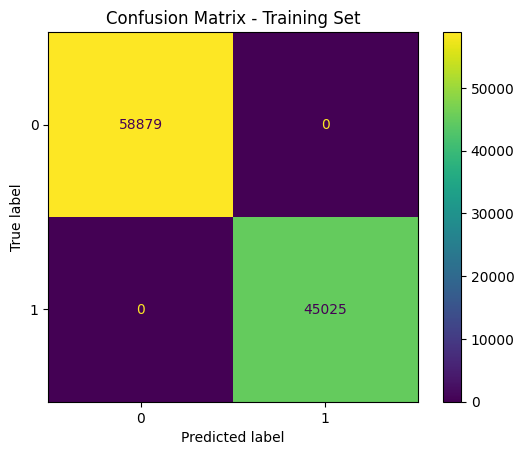

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp_train = ConfusionMatrixDisplay.from_estimator(dt, train_X, train_y)

plt.title("Confusion Matrix - Training Set")
plt.show()


Accuracy: 0.9489528795811518
Precision: 0.9422452383042219
Recall: 0.9414189248443392
F1: 0.9418319003333918


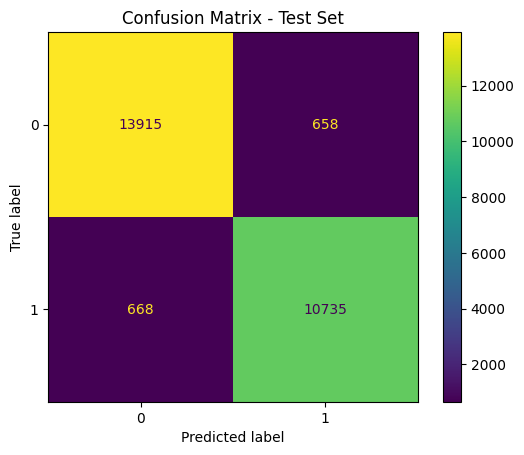

In [11]:
#Predict on test set

from sklearn.metrics import accuracy_score

y_pred = dt.predict(test_X)

accuracy = accuracy_score(test_y, y_pred)


from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
print("")
print("Accuracy:", accuracy_score(test_y, y_pred))
print("Precision:", precision_score(test_y, y_pred))
print("Recall:", recall_score(test_y, y_pred))
print("F1:", f1_score(test_y, y_pred))


# Generate and plot confusion matrix for the test set
disp_test = ConfusionMatrixDisplay.from_estimator(dt, test_X, test_y)

# Plot the confusion matrix
plt.title("Confusion Matrix - Test Set")
plt.show()

Max Depth: 1, Training Accuracy: 0.788, Test Accuracy: 0.783
Max Depth: 2, Training Accuracy: 0.857, Test Accuracy: 0.855
Max Depth: 3, Training Accuracy: 0.885, Test Accuracy: 0.884
Max Depth: 4, Training Accuracy: 0.893, Test Accuracy: 0.893
Max Depth: 5, Training Accuracy: 0.906, Test Accuracy: 0.906
Max Depth: 6, Training Accuracy: 0.921, Test Accuracy: 0.919
Max Depth: 7, Training Accuracy: 0.935, Test Accuracy: 0.932
Max Depth: 8, Training Accuracy: 0.943, Test Accuracy: 0.939
Max Depth: 9, Training Accuracy: 0.949, Test Accuracy: 0.946
Max Depth: 10, Training Accuracy: 0.955, Test Accuracy: 0.950


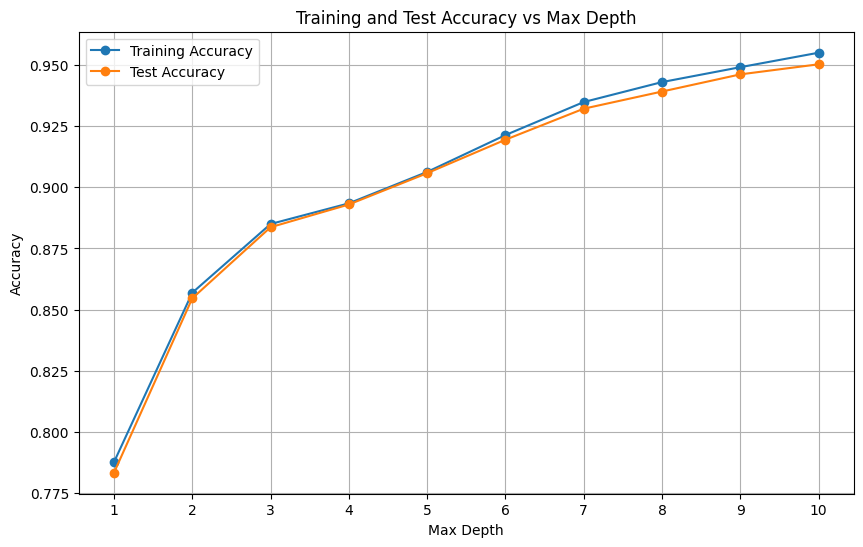

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Range of max_depth values to test
max_depth_range = range(1, 11)

# Lists to store the training and test accuracies for each max_depth
train_accuracies = []
test_accuracies = []

# Iterate through max_depth values
for depth in max_depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=0, criterion= "entropy")
    # Train the model on the training data
    clf.fit(train_X, train_y)

    # Evaluate the model on the training data
    train_accuracy = clf.score(train_X, train_y)
    train_accuracies.append(train_accuracy)

    # Evaluate the model on the test data
    test_accuracy = clf.score(test_X, test_y)
    test_accuracies.append(test_accuracy)

    print(f"Max Depth: {depth}, Training Accuracy: {train_accuracy:.3f}, Test Accuracy: {test_accuracy:.3f}")

# Plot the training and test accuracies vs max_depth
plt.figure(figsize=(10, 6))
plt.plot(max_depth_range, train_accuracies, marker='o', label="Training Accuracy")
plt.plot(max_depth_range, test_accuracies, marker='o', label="Test Accuracy")
plt.title('Training and Test Accuracy vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(max_depth_range)
plt.legend()
plt.grid(True)
plt.show()

Choose max_depth = 7 to prevent overfitting (optimize complexity)

In [13]:
tree_pruned = DecisionTreeClassifier(max_depth=7, random_state=0, criterion= "entropy")
tree_pruned.fit(train_X, train_y)
y_pruned_pred = tree_pruned.predict(test_X)

#from sklearn.metrics import accuracy_score
print("Accuracy on training set:",round(tree_pruned.score(train_X, train_y),3))
print("Accuracy on test set:",accuracy_score(y_pruned_pred, test_y))

Accuracy on training set: 0.935
Accuracy on test set: 0.9320526639975362


In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(test_y, y_pred))
print("Precision:", precision_score(test_y, y_pred))
print("Recall:", recall_score(test_y, y_pred))
print("F1:", f1_score(test_y, y_pred))


Accuracy: 0.9489528795811518
Precision: 0.9422452383042219
Recall: 0.9414189248443392
F1: 0.9418319003333918


In [15]:
# Feature Importance

# Get feature importances from the pruned tree model
feature_importances = tree_pruned.feature_importances_

# Create a DataFrame of feature importances
feature_importance_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance DataFrame
print("Feature Importance for the Pruned Decision Tree:")
display(feature_importance_df)

Feature Importance for the Pruned Decision Tree:


,Feature,Importance
17,Online boarding,0.387218
12,Inflight wifi service,0.229230
4,Type of Travel_Business travel,0.147783
19,Inflight entertainment,0.061527
6,Class_Business,0.054140
3,Customer Type_disloyal Customer,0.035505
23,Checkin service,0.020439
15,Gate location,0.020420
5,Type of Travel_Personal Travel,0.011729
2,Customer Type_Loyal Customer,0.008635
